In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import mat73
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_rel
from itertools import chain
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from GLM_regression import *
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

def preprocess_data(filepath, normalize=True):
    data_dict = mat73.loadmat(filepath)

    # Define new position variables to use as input for the GLM
    num_spatial_bins = 10
    position_matrix = np.zeros((50, num_spatial_bins))
    bin_size = 50//num_spatial_bins
    for i in range(num_spatial_bins):
        position_matrix[i*bin_size:(i+1)*bin_size,i] = 1

    reorganized_data = {}
    variable_list = []

    for animal_idx, (delta_f,velocity,lick_rate,reward_loc) in enumerate(zip(data_dict['animal']['ShiftR'], data_dict['animal']['ShiftRunning'], data_dict['animal']['ShiftLrate'], data_dict['animal']['ShiftV'])):
        reorganized_data[f'animal_{animal_idx + 1}'] = {}

        for i, neuron_idx in enumerate(range(delta_f.shape[2])):
            if np.all(np.isnan(delta_f[:,:,neuron_idx])) or np.all(delta_f[:,:,neuron_idx] == 0):
                continue

            neuron_data = []
            
            # Neuron activity
            neuron_data.append(delta_f[:,:,neuron_idx]) 
            variable_list.append('Activity') if 'Activity' not in variable_list else None
            
            # Lick rate
            neuron_data.append(lick_rate)  
            variable_list.append('Licks') if 'Licks' not in variable_list else None

            # Reward location (valve opening)
            neuron_data.append(reward_loc)
            variable_list.append('Reward_loc') if 'Reward_loc' not in variable_list else None

            # Running speed
            neuron_data.append(velocity)
            variable_list.append('Velocity') if 'Velocity' not in variable_list else None

            ####################################################
            # TODO: EC_GLM.mat has a data mismatch (missing trial in neuron activity). Check with Christine
            num_trials = np.min([neuron_data[i].shape[1] for i in range(len(neuron_data))])
            for i in range(len(neuron_data)):
                neuron_data[i] = neuron_data[i][:, :num_trials]
            ####################################################

            neuron_data = np.stack(neuron_data, axis=1)

            # Add position variables to the data matrix
            expanded_position_matrix = np.repeat(position_matrix[:, :, np.newaxis], neuron_data.shape[2], axis=2) # Copy along the 'trials' dimension
            neuron_data = np.concatenate((neuron_data, expanded_position_matrix), axis=1)
            variable_list.extend([f'#{i}' for i in range(1, num_spatial_bins+1)]) if f'#{i}' not in variable_list else None

            # Filter out NaN trials
            neuron_data = neuron_data[:, :, ~np.isnan(neuron_data).any(axis=(0, 1))]

            if normalize:
                neuron_data = normalize_data(neuron_data)

            reorganized_data[f'animal_{animal_idx + 1}'][f'cell_{neuron_idx + 1}'] = neuron_data

    return reorganized_data, variable_list




datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_SST = "SSTindivsomata_GLM"
filepath_SST = os.path.join(datasets_dir, filename_SST+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_NDNF = "NDNFindivsomata_GLM"
filepath_NDNF = os.path.join(datasets_dir, filename_NDNF+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_EC = "EC_GLM"
filepath_EC = os.path.join(datasets_dir, filename_EC+".mat")


reorganized_data, variable_list = preprocess_data(filepath_SST)
GLM_params = fit_GLM(reorganized_data, quintile=None, regression='ridge')

In [27]:
def compute_residual_activity(GLM_params, reorganized_data, quintile=None):
    neuron_activity_list = []
    predicted_activity_list = []
    residual_activity = {}
    avg_residuals = []
    for animal in GLM_params:
        residual_activity[animal] = {}
        for neuron in GLM_params[animal]:
            # Pre-process the data
            neuron_data = reorganized_data[animal][neuron]
            if quintile is not None:
                num_trials = neuron_data.shape[2]
                start_idx,end_idx = get_quintile_indices(num_trials, quintile)
                neuron_data = neuron_data[:, :, start_idx:end_idx]

            flattened_data = flatten_data(neuron_data)
            neuron_activity = neuron_data[:,0,:]

            # Predict activity and compute residuals
            glm_model = GLM_params[animal][neuron]['model']
            flattened_input_variables = flattened_data[:,1:]
            print(f"flattened_input_variables {flattened_input_variables}") #######################
            predicted_activity = glm_model.predict(flattened_input_variables)
            predicted_activity = predicted_activity.reshape(neuron_activity.shape)
            predicted_activity_list.append(predicted_activity)
            neuron_activity_list.append(neuron_activity)
            residual_activity[animal][neuron] = neuron_activity - predicted_activity

            avg_residuals.append(np.mean(residual_activity[animal][neuron], axis=1))

    avg_residuals = np.array(avg_residuals)
    return residual_activity, avg_residuals, predicted_activity_list, neuron_activity_list

In [28]:
def remove_variables_from_glm(GLM_params, vars_to_remove, variable_list):
    GLM_params_ = copy.deepcopy(GLM_params)

    idx_to_remove = [variable_list[1:].index(var) for var in vars_to_remove if var in variable_list[1:]]

    modified_GLM_params = {}
    for animal_key, neurons in GLM_params_.items():
        modified_GLM_params[animal_key] = {}
        for neuron_idx, params in neurons.items():
            params['model'].coef_[idx_to_remove] = 0
            if "intercept" in vars_to_remove:
                params['model'].intercept_ = 0
                params['intercept'] = 0
            print(f"params {params}") ####################################
            modified_GLM_params[animal_key][neuron_idx] = params

    return modified_GLM_params

In [ ]:
def fit_GLM_with_variable_removal(reorganized_data, variable_list, variables_to_fit=["all"], quintile=None, regression='ridge', renormalize=True, alphas=None):
    GLM_params = {}
    for animal in reorganized_data:
        GLM_params[animal] = {}
        count=0
        for neuron, neuron_data in reorganized_data[animal].items():
            print(f"count{count}")
            neuron_data = neuron_data[:,:,~np.isnan(neuron_data).any(axis=(0,1))]

            if quintile is not None:
                num_trials = neuron_data.shape[2]
                start_idx,end_idx = get_quintile_indices(num_trials, quintile)
                neuron_data = neuron_data[:, :, start_idx:end_idx]
                
                
                
            if renormalize:
                neuron_data = normalize_data(neuron_data)
                
            
                     
            flattened_data = flatten_data(neuron_data)
            design_matrix_X = flattened_data[:, 1:].copy() 
            
            if variables_to_fit == ["all"]:

                pass
            else:
                # Find indices to keep
                indices_to_keep = []
                for variable in variables_to_fit:
                    if variable in variable_list:
                        indices_to_keep.append(variable_list.index(variable) - 1)  
                    else:
                        raise ValueError(f"Variable '{variable}' not found in variable_list.")

                indices_to_remove = [i for i in range(design_matrix_X.shape[1]) if i not in indices_to_keep]
                design_matrix_X[:, indices_to_remove] = 0


            neuron_activity = flattened_data[:, 0]
                     
           
            
            print(f"design_matrix_x {design_matrix_X}")
            neuron_activity = flattened_data[:,0]
            print(f"neuron_activity {neuron_activity.shape}")

            if regression == 'lasso':
                model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
            elif regression == 'ridge':
                model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
            elif regression == 'elastic':
                l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
                model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], l1_ratio=l1_ratio, cv=None)
            else:
                raise ValueError("Regression type must be 'lasso' or 'ridge'")

            model.fit(design_matrix_X, neuron_activity)

            predicted_activity = model.predict(design_matrix_X)
            trialavg_neuron_activity = np.mean(neuron_data[:,0,:], axis=1)
            trialavg_predicted_activity = np.mean(predicted_activity.reshape(neuron_data[:,0,:].shape), axis=1)
            pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0,1]

            GLM_params[animal][neuron] = {
                'weights': model.coef_,
                'intercept': model.intercept_,
                'alpha': model.alpha_ if regression == 'ridge' else model.alpha_,
                'l1_ratio': model.l1_ratio_ if regression == 'elastic' else None,
                'R2': model.score(design_matrix_X, neuron_activity),
                'R2_trialavg': pearson_R**2,
                'model': model
            }
            count+=1
            
            
    return GLM_params


GLM_params = fit_GLM_with_variable_removal(reorganized_data, variable_list, variables_to_fit=["Velocity"], quintile=None, regression='ridge', renormalize=True, alphas=None)

In [29]:
def compute_variable_subtracted_residuals_variable_removal(reorganized_data, variable_list, quintile, variables_to_fit=["Velocity"], variables_to_remove=["Velocity"]):
    
    GLM_params = fit_GLM_with_variable_removal(reorganized_data, variable_list, variables_to_fit, quintile=None, regression='ridge', renormalize=True, alphas=None)
    
    vars_to_remove = variable_list.copy()[1:] + ['intercept']
    removing_list = []
 
    for variable in variables_to_remove:
        if variable in variable_list:
            index = variable_list.index(variable)
            removing_list.append(index)

    for index in removing_list:
        vars_to_remove.remove(variable_list[index])
        
    print(f"vars_to_remove {vars_to_remove}") ###############################

    filtered_GLM_params = remove_variables_from_glm(GLM_params, vars_to_remove, variable_list)
    residual_activity, avg_residuals, predicted_activity, neuron_activity_list = compute_residual_activity(filtered_GLM_params, reorganized_data,
                                                                 quintile=quintile)
    return avg_residuals, GLM_params, residual_activity, predicted_activity, neuron_activity_list


avg_residuals, GLM_params, residual_activity, predicted_activity, neuron_activity_list = compute_variable_subtracted_residuals_variable_removal(reorganized_data, variable_list, quintile=None, variables_to_fit=["Velocity"], variables_to_remove=["Velocity"])

count0
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (10600,)
count1
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (10600,)
count2
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (10600,)
count3
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (10600,)
count4
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (10600,)
count0
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (7600,)
count1
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (7600,)
count2
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (7600,)
count3
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (7600,)
count4
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (7600,)
count5
indices_to_remove [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
neuron_activity (7600,)
count6
indices_t

flattened_input_variables [[0.         0.         0.52389345 ... 0.         0.         0.        ]
 [0.3315992  0.         0.35421396 ... 0.         0.         0.        ]
 [0.         0.         0.51839454 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.37289165 ... 0.         0.         1.        ]
 [0.         0.         0.24057056 ... 0.         0.         1.        ]
 [0.         0.         0.14217343 ... 0.         0.         1.        ]]
flattened_input_variables [[0.         0.         0.52389345 ... 0.         0.         0.        ]
 [0.3315992  0.         0.35421396 ... 0.         0.         0.        ]
 [0.         0.         0.51839454 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.37289165 ... 0.         0.         1.        ]
 [0.         0.         0.24057056 ... 0.         0.         1.        ]
 [0.         0.         0.14217343 ... 0.         0.         1.        ]]
flattened_input_variables [[0.         0.         0.52389345

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


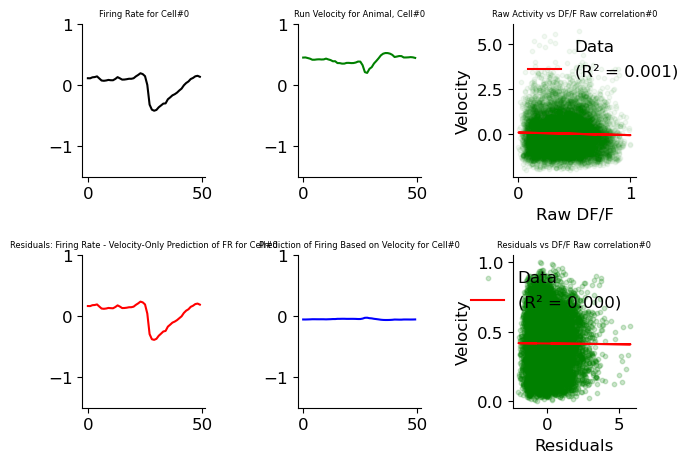

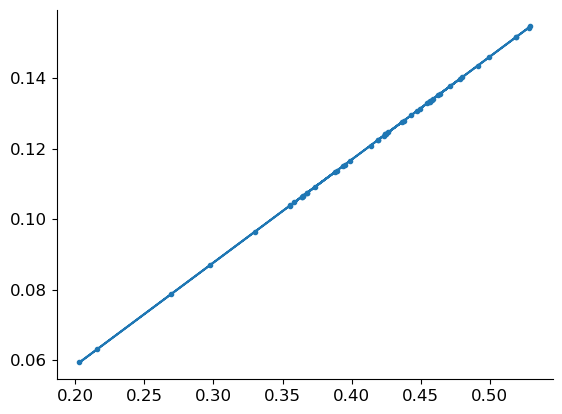

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


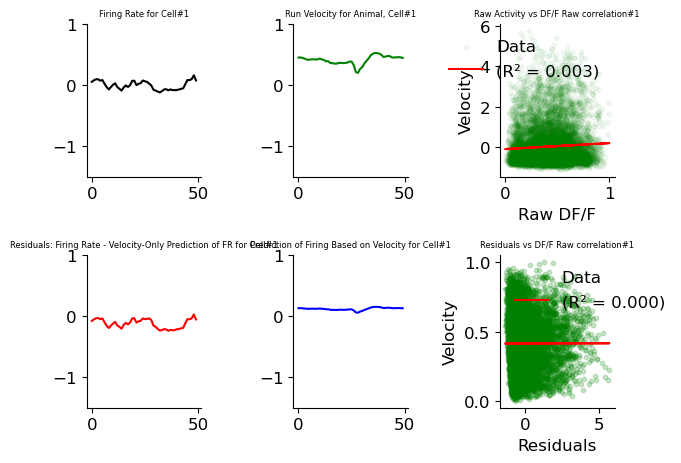

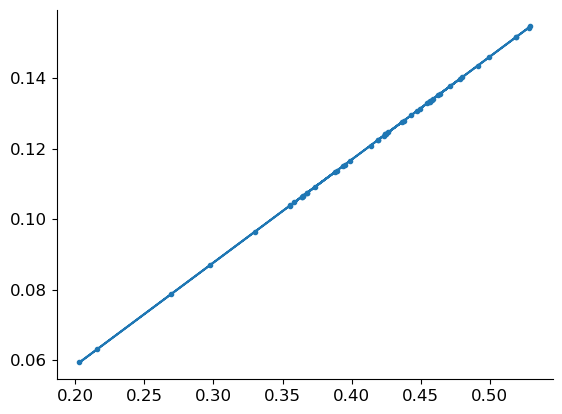

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


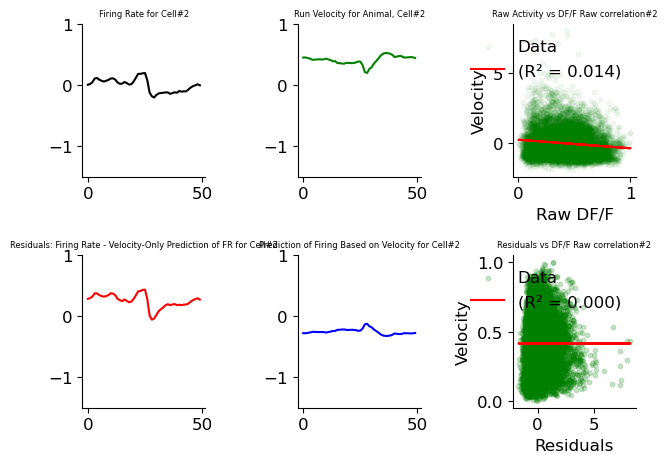

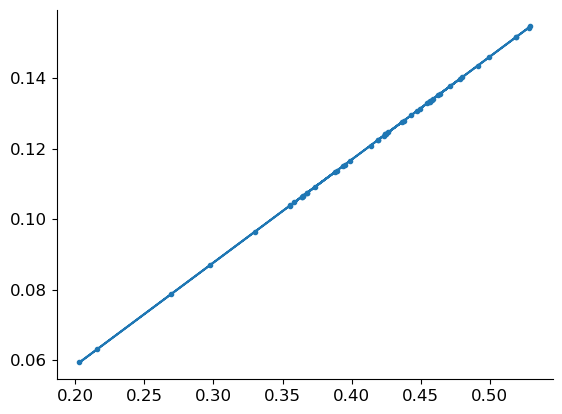

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


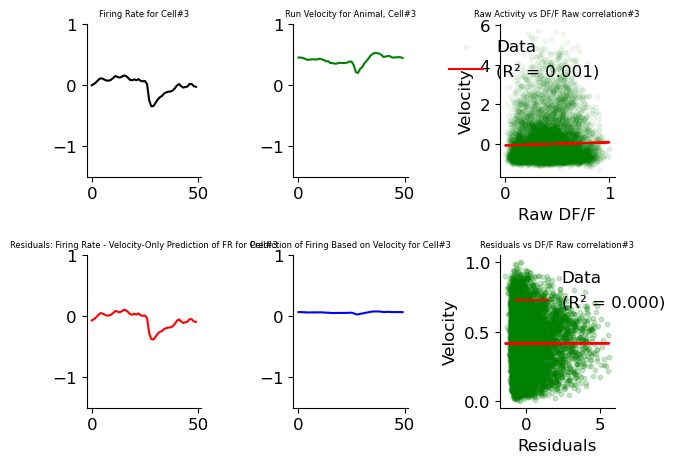

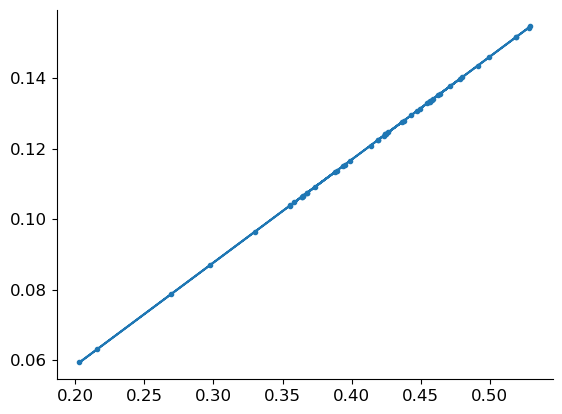

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


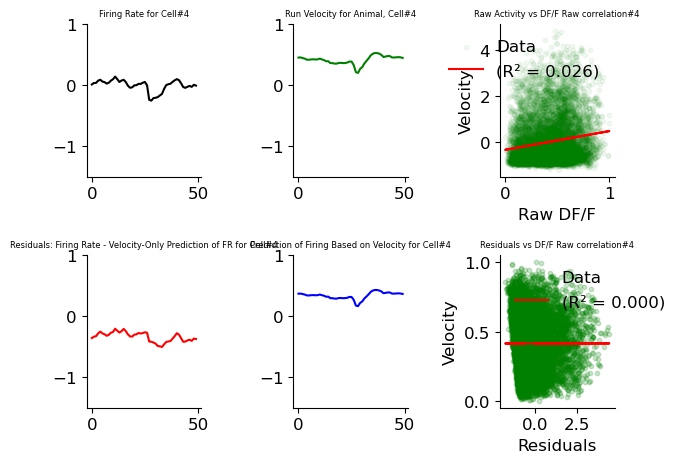

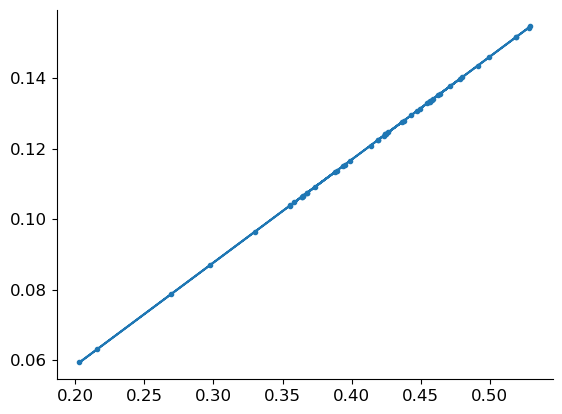

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


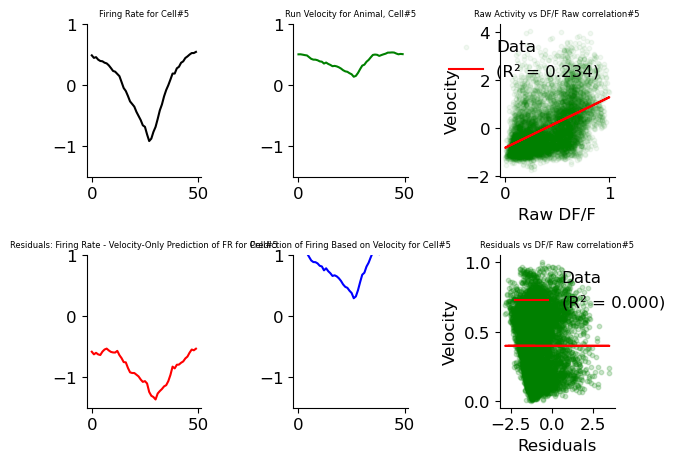

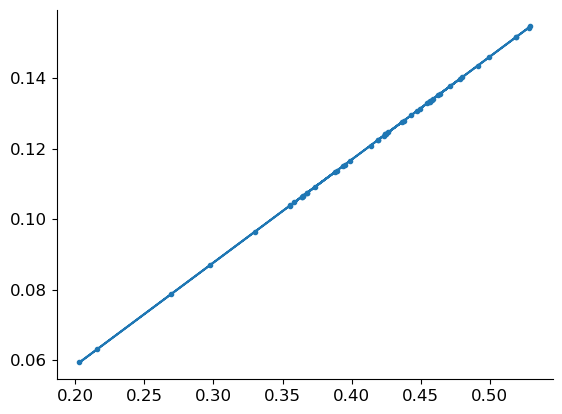

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


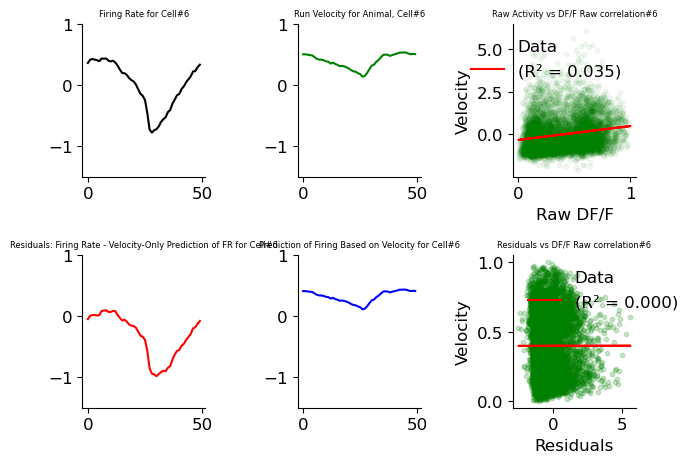

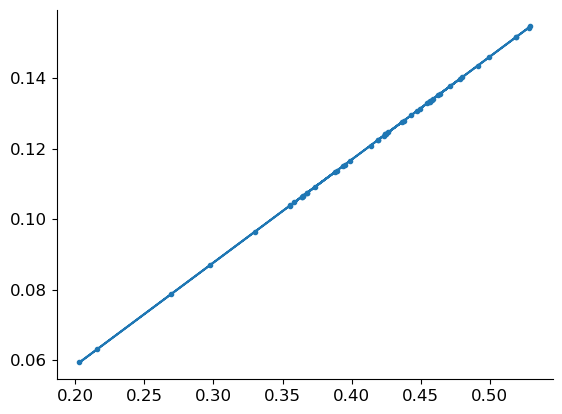

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


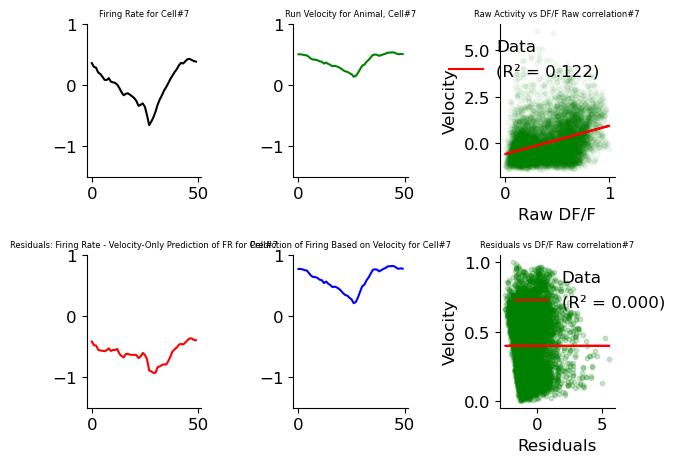

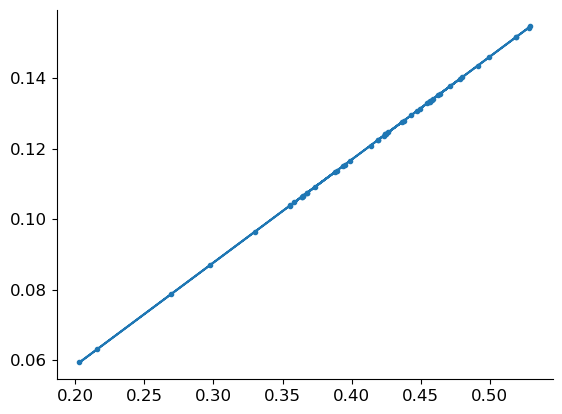

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


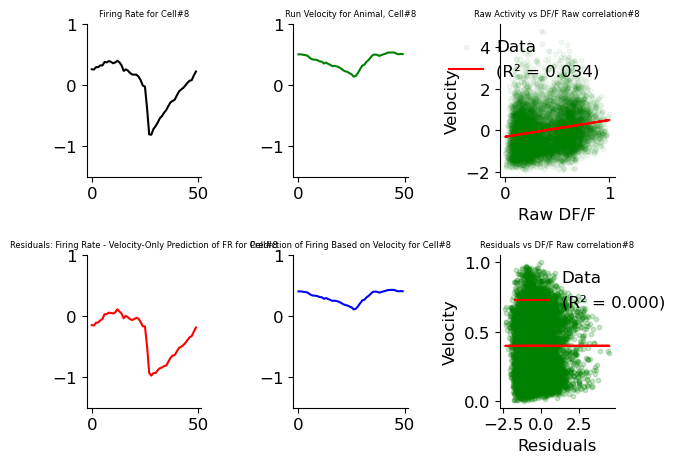

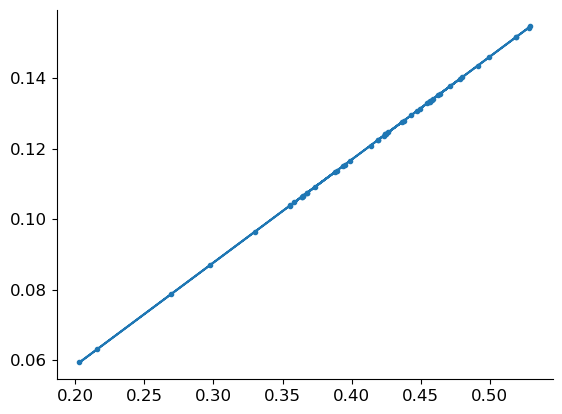

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


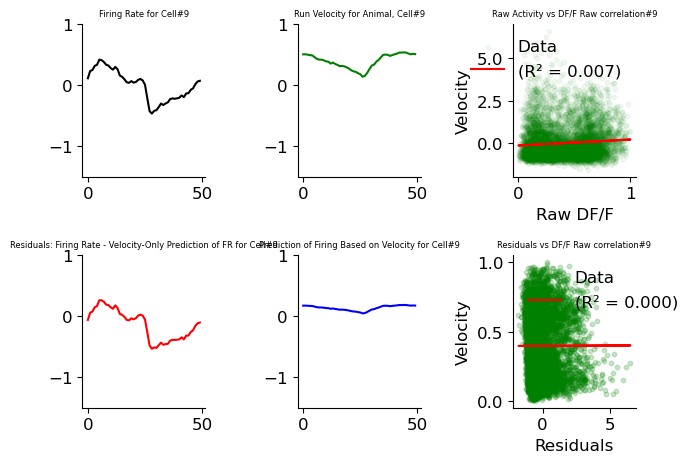

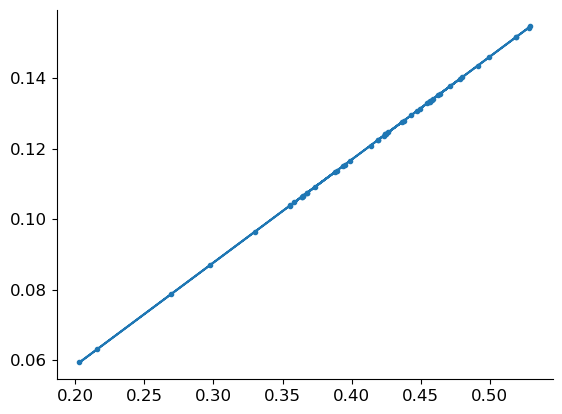

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3072831499.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


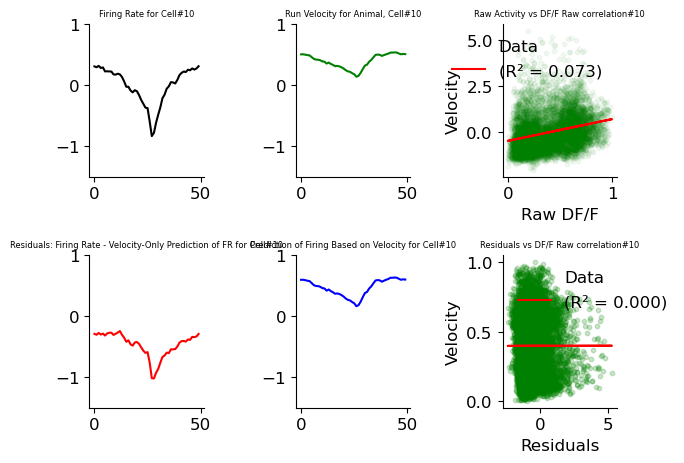

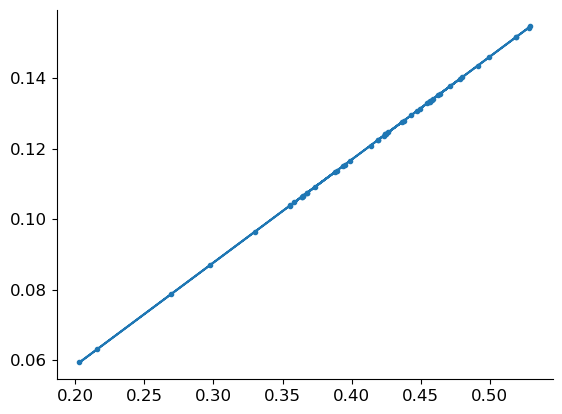

In [30]:
cells = np.arange(0,11)
    
for i in cells:
    r2_list_activity_zero, r2_list_residuals_zero = plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals_gone(reorganized_data, neuron_activity_list, predicted_activity, residual_activity, i)

In [ ]:

avg_residuals, GLM_params, residual_activity_position, predicted_activity_position, neuron_activity_list_position = compute_variable_subtracted_residuals_variable_removal(reorganized_data, variable_list, quintile=None, variables_to_fit=["Position"], variables_to_remove=["Velocity"])

In [2]:
def fit_GLM_to_only_velocity_gone(reorganized_data, quintile=None, regression='ridge', renormalize=True, alphas=None):
    GLM_params = {}
    for animal in reorganized_data:
        GLM_params[animal] = {}
        count=0
        for neuron, neuron_data in reorganized_data[animal].items():
            print(f"count{count}")
            neuron_data = neuron_data[:,:,~np.isnan(neuron_data).any(axis=(0,1))]

            if quintile is not None:
                num_trials = neuron_data.shape[2]
                start_idx,end_idx = get_quintile_indices(num_trials, quintile)
                neuron_data = neuron_data[:, :, start_idx:end_idx]
                
                
                
            if renormalize:
                neuron_data = normalize_data(neuron_data)
                
            

            flattened_data = flatten_data(neuron_data)
            design_matrix_X = flattened_data[:, 3].reshape(-1, 1)
            
            print(f"design_matrix_X.shape {design_matrix_X.shape}")
            neuron_activity = flattened_data[:,0]
            print(f"neuron_activity {neuron_activity.shape}")

            if regression == 'lasso':
                model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
            elif regression == 'ridge':
                model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
            elif regression == 'elastic':
                l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
                model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], l1_ratio=l1_ratio, cv=None)
            else:
                raise ValueError("Regression type must be 'lasso' or 'ridge'")

            model.fit(design_matrix_X, neuron_activity)

            predicted_activity = model.predict(design_matrix_X)
            trialavg_neuron_activity = np.mean(neuron_data[:,0,:], axis=1)
            trialavg_predicted_activity = np.mean(predicted_activity.reshape(neuron_data[:,0,:].shape), axis=1)
            pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0,1]

            GLM_params[animal][neuron] = {
                'weights': model.coef_,
                'intercept': model.intercept_,
                'alpha': model.alpha_ if regression == 'ridge' else model.alpha_,
                'l1_ratio': model.l1_ratio_ if regression == 'elastic' else None,
                'R2': model.score(design_matrix_X, neuron_activity),
                'R2_trialavg': pearson_R**2,
                'model': model
            }
            count+=1
            
            
    return GLM_params


GLM_params = fit_GLM_to_only_velocity_gone(reorganized_data, quintile=None, regression='ridge', renormalize=True, alphas=None)


count0
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count1
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count2
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count3
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count4
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count0
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count1
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count2
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count3
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count4
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count5
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count6
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count7
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count8
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count9
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count10
design_matrix_X.shape (7600, 1)
neuro

In [3]:
def compute_residual_activity_gone(GLM_params, reorganized_data, quintile=None):
    neuron_activity_list = []
    predicted_activity_list = []
    residual_activity = {}
    avg_residuals = []
    for animal in GLM_params:
        residual_activity[animal] = {}
        for neuron in GLM_params[animal]:
            # Pre-process the data
            neuron_data = reorganized_data[animal][neuron]
            if quintile is not None:
                num_trials = neuron_data.shape[2]
                start_idx,end_idx = get_quintile_indices(num_trials, quintile)
                neuron_data = neuron_data[:, :, start_idx:end_idx]

            flattened_data = flatten_data(neuron_data)
            neuron_activity = neuron_data[:,0,:]

            # Predict activity and compute residuals
            glm_model = GLM_params[animal][neuron]['model']
            flattened_input_variables = flattened_data[:,3]
            flattened_input_variables = flattened_input_variables.reshape(-1, 1)

            print(f"flattened_input_variables {flattened_input_variables}") #######################
            predicted_activity = glm_model.predict(flattened_input_variables)
            predicted_activity = predicted_activity.reshape(neuron_activity.shape)
            predicted_activity_list.append(predicted_activity)
            neuron_activity_list.append(neuron_activity)
            residual_activity[animal][neuron] = neuron_activity - predicted_activity

            avg_residuals.append(np.mean(residual_activity[animal][neuron], axis=1))

    avg_residuals = np.array(avg_residuals)
    return residual_activity, avg_residuals, predicted_activity_list, neuron_activity_list

In [4]:
def compute_variable_subtracted_residuals_only_velocity_gone(reorganized_data, variable_list, variables_to_remove, quintile):
    #fit a GLM for all variables 
    GLM_params = fit_GLM_to_only_velocity_gone(reorganized_data, quintile=quintile, regression='ridge', renormalize=False)
#     vars_to_remove = 
#     vars_to_remove = variable_list.copy()[1:] + ['intercept']
#     removing_list = []

#     #look through the list of variables you try to remove - velocity or licks, etc 
#     for variable in variables_to_remove:
#         if variable in variable_list:
#             index = variable_list.index(variable)
#             removing_list.append(index)

#     for index in removing_list:
#         vars_to_remove.remove(variable_list[index])
        
#     print(f"vars_to_remove {vars_to_remove}") ###############################

#     filtered_GLM_params = fake_remove_variables_from_glm(GLM_params, vars_to_remove, variable_list)
    residual_activity, avg_residuals, predicted_activity, neuron_activity_list = compute_residual_activity_gone(GLM_params, reorganized_data,
                                                                 quintile=quintile)
    return avg_residuals, GLM_params, residual_activity, predicted_activity, neuron_activity_list

vel_only_avg_residuals_zero_gone, vel_only_GLM_params_zero_gone, vel_only_residual_activity_zero_gone, vel_only_vel_predicted_activity_zero_gone, vel_only_neuron_activity_list_zero_gone = compute_variable_subtracted_residuals_only_velocity_gone(reorganized_data, variable_list, [], quintile=None)

count0
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count1
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count2
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count3
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count4
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count0
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count1
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count2
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count3
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count4
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count5
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count6
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count7
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count8
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count9
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count10
design_matrix_X.shape (7600, 1)
neuro

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


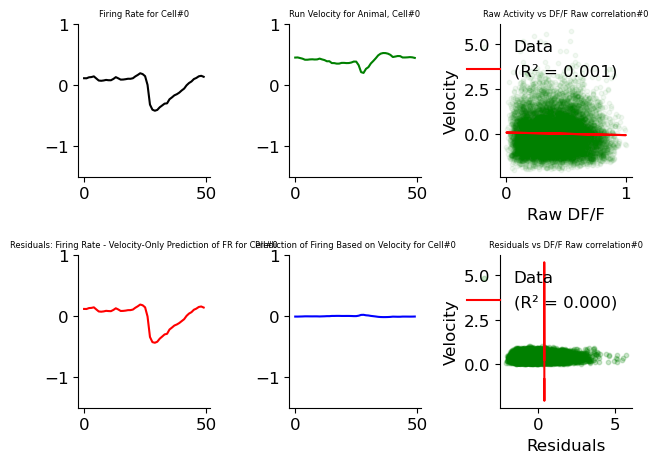

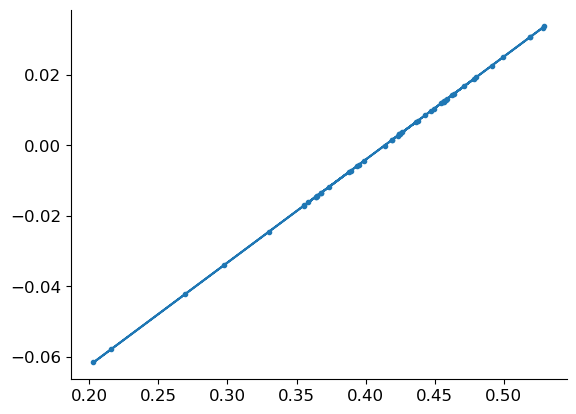

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


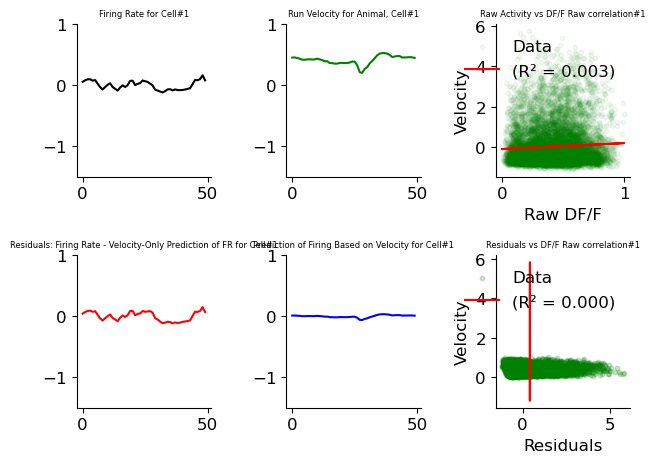

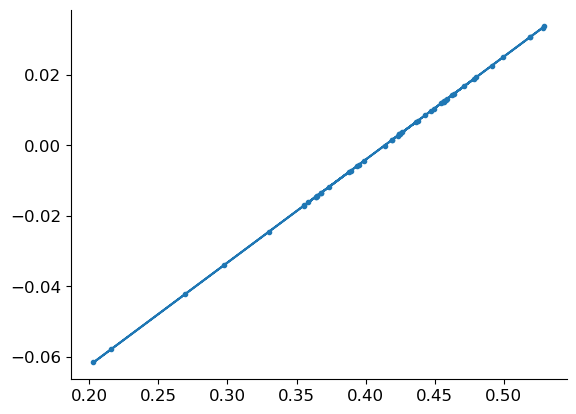

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


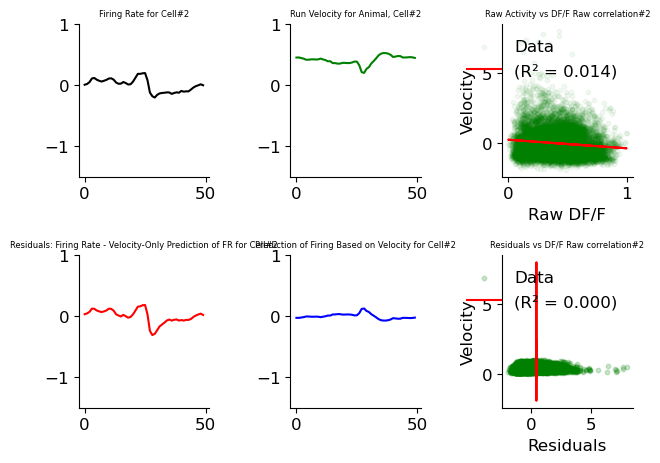

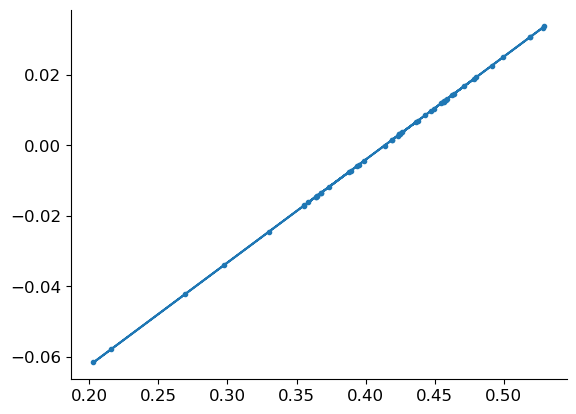

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


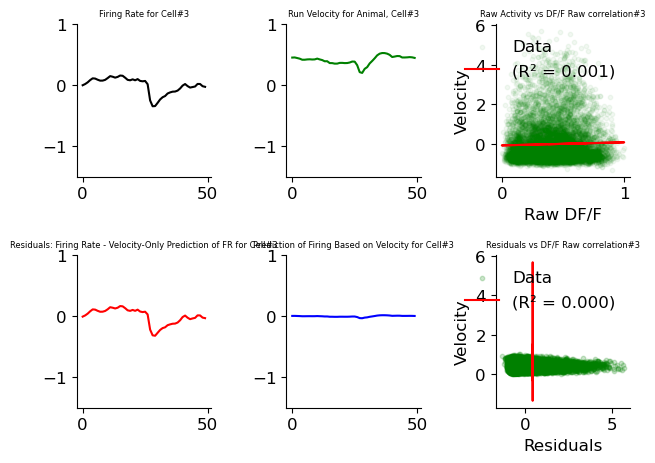

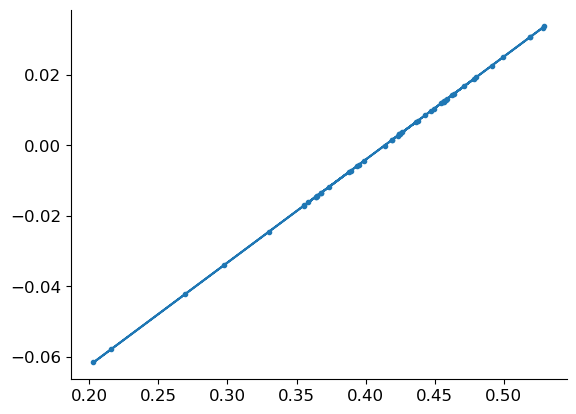

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


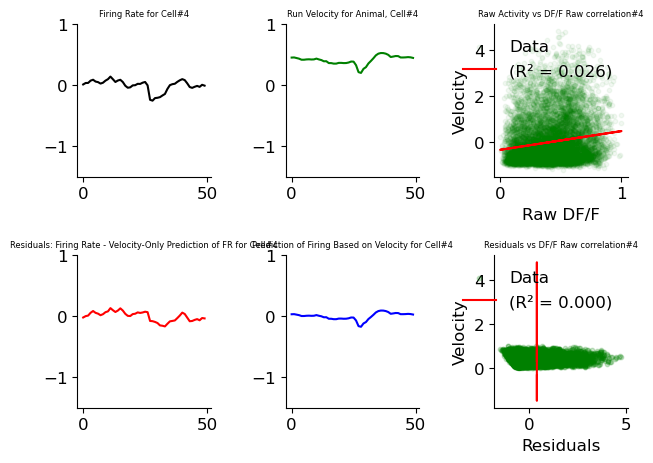

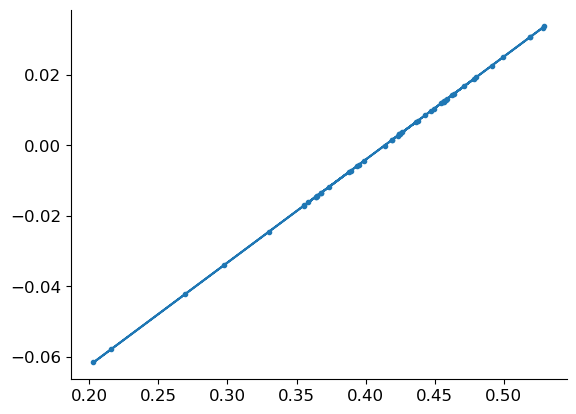

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


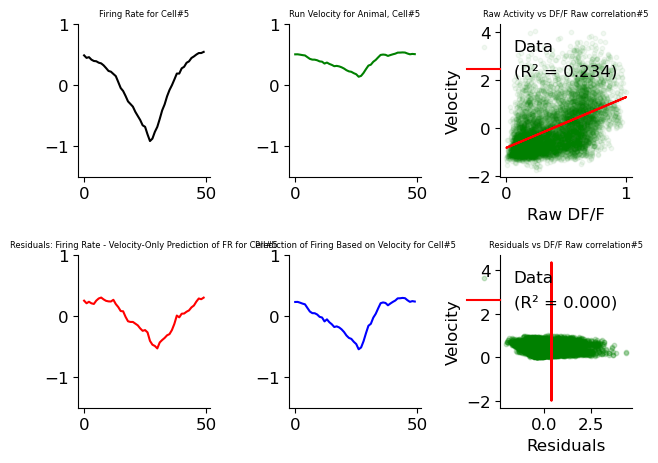

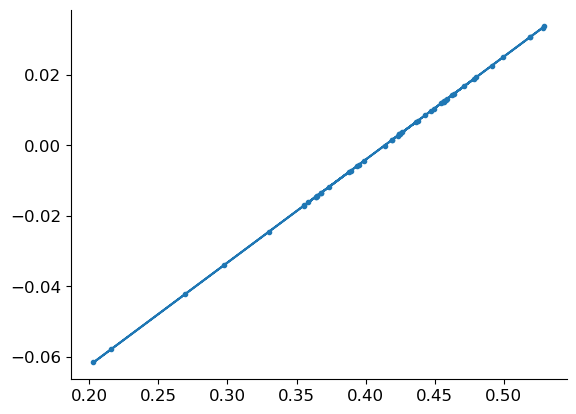

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


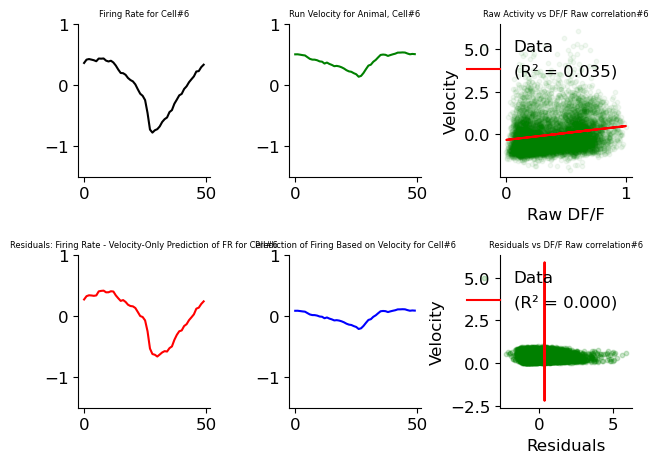

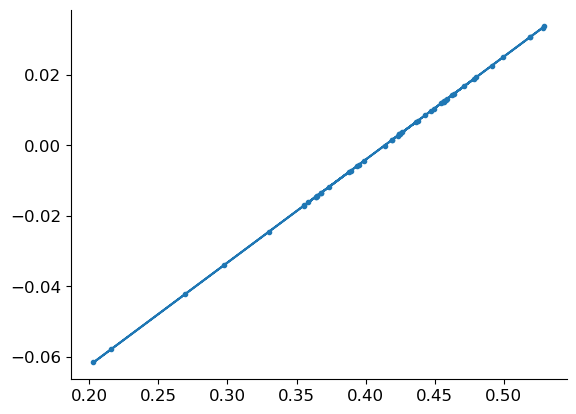

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


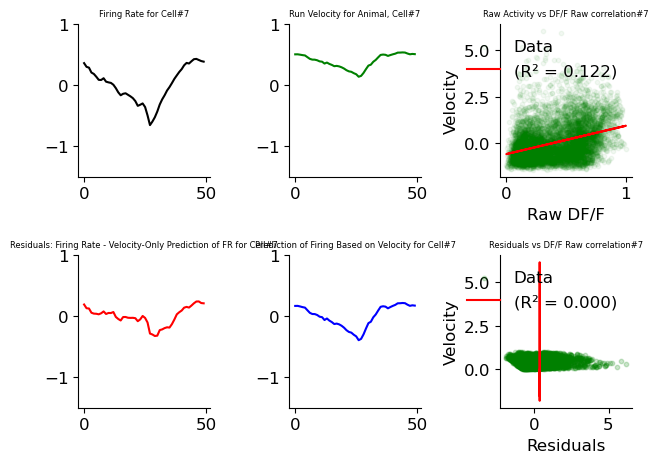

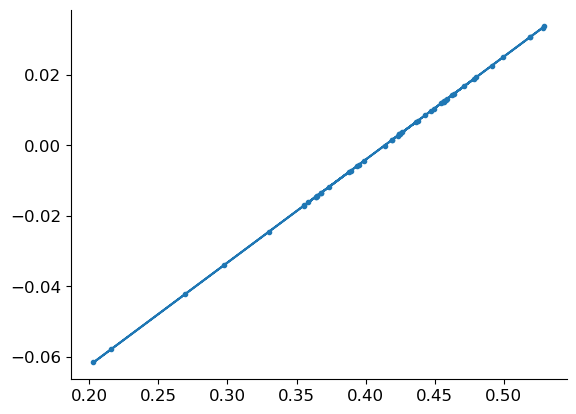

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


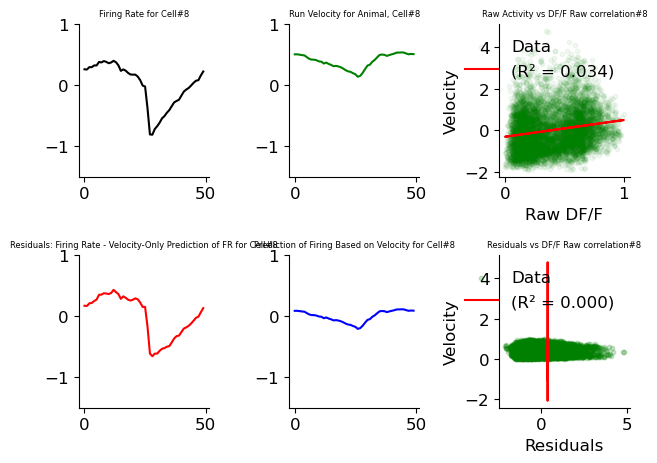

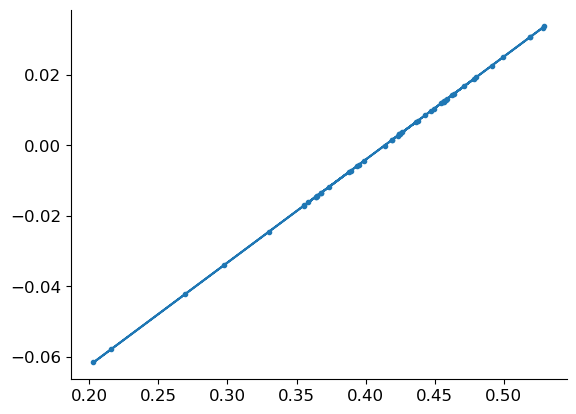

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


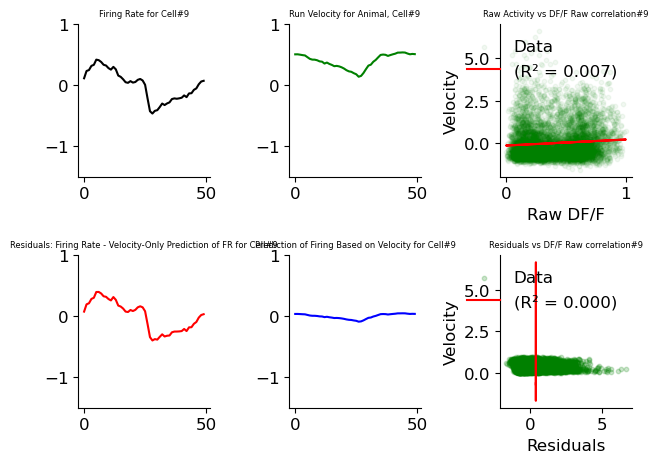

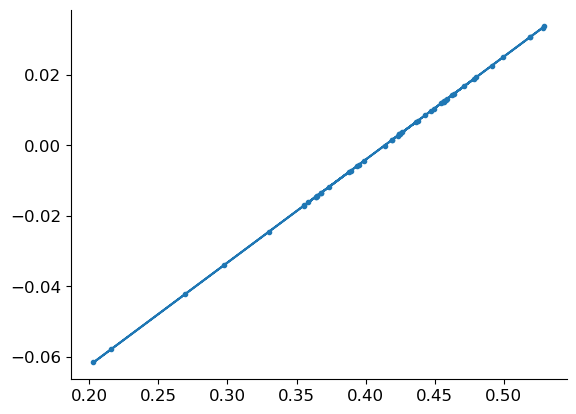

C:\Users\Msfin\AppData\Local\Temp\ipykernel_20512\3837839052.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


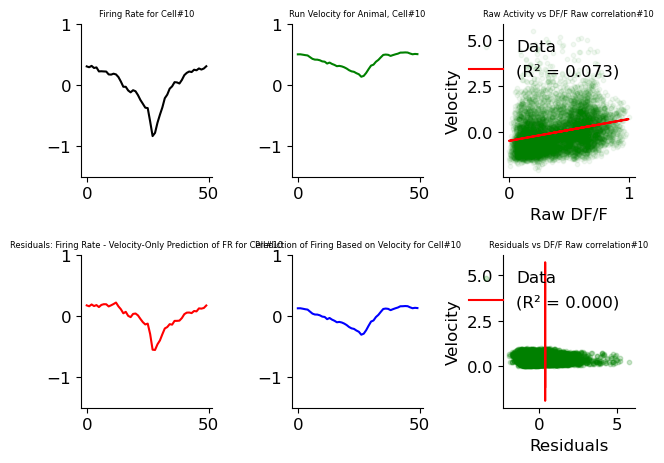

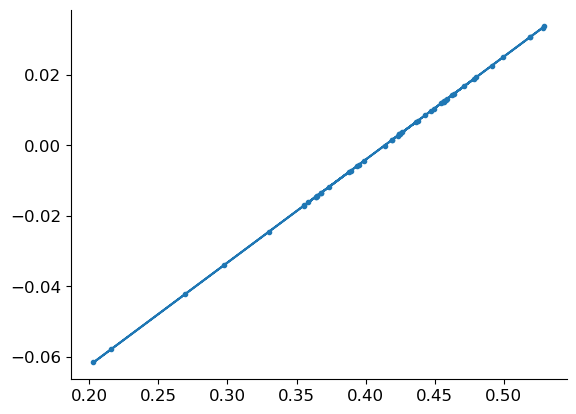

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals_gone(reorganized_data, vel_only_neuron_activity_list_zero_gone, vel_only_vel_predicted_activity_zero_gone, vel_only_residual_activity_zero_gone, cell_number):
    
    cell_number = int(cell_number)
    
    trial_average_velocity_list = []
    velocity_list = []
    for animal, subdict in reorganized_data.items():
            for cell, value in subdict.items():
                neuron_data = reorganized_data[animal][cell]
                velocity = neuron_data[:, 3, :]
                velocity_list.append(velocity)
                trial_average_velocity_list.append(np.mean(velocity, axis=1))

    list_of_2d_velocities = [np.vstack(arrays) for arrays in velocity_list]
    
    
    all_vel_only_residual_activity_zero_gone = []
    for key, value in vel_only_residual_activity_zero_gone.items():
        for subkey, subdict in value.items():
            all_vel_only_residual_activity_zero_gone.append(subdict)

    trial_av_residuals_list = []
    for i in all_vel_only_residual_activity_zero_gone:
        trial_av_residuals_list.append(np.mean(i, axis=1))
    


    trial_av_velocity_prediction_list = []
    for i in vel_only_vel_predicted_activity_zero_gone:
        trial_av_velocity_prediction_list.append(np.mean(i, axis=1))

        
    trial_av_neuron_activity_list = []
    for i in vel_only_neuron_activity_list_zero_gone:
        trial_av_neuron_activity_list.append(np.mean(i, axis=1))
        
        
   

    fig, axs = plt.subplots(2,3)

    

    axs[0,0].plot(trial_av_neuron_activity_list[cell_number], color='k', label='neuron activity')
    axs[0,0].set_title(f"Firing Rate for Cell#{cell_number}", fontsize=6)
    axs[0,0].set_ylim(-1.5, 1)

    axs[0,1].plot(trial_average_velocity_list[cell_number], color='g')
    axs[0,1].set_title(f"Run Velocity for Animal, Cell#{cell_number}", fontsize=6)
    axs[0,1].set_ylim(-1.5, 1)
    
    
    flattened_velocity_list = []
    for i in velocity_list:
        flattened_velocity_list.append(i.flatten())
    
    
    flattened_activity_list = []
    for i in vel_only_neuron_activity_list_zero_gone:
        flattened_activity_list.append(i.flatten())
        
    
    r2_list_activity = []
    y_pred_list = []
    x_list = []
    y_list = []
    
    for cell in range(len(velocity_list)):
    
        x = np.array(flattened_velocity_list[cell])
        x_list.append(x)
        y = np.array(flattened_activity_list[cell])
        y_list.append(y)

        x_reshaped = x.reshape(-1, 1)  
        model = LinearRegression()
        model.fit(x_reshaped, y)

        y_pred = model.predict(x_reshaped)
        y_pred_list.append(y_pred)

        r2 = r2_score(y, y_pred)
        r2_list_activity.append(r2)

    axs[0,2].scatter(flattened_velocity_list[cell_number], flattened_activity_list[cell_number], color='g', s=10, alpha=0.05, label='Data')                           
    axs[0,2].plot(flattened_velocity_list[cell_number], y_pred_list[cell_number], color='r', label=f'(R² = {r2_list_activity[cell_number]:.3f})')
    axs[0,2].set_title(f"Raw Activity vs DF/F Raw correlation#{cell_number}", fontsize=6)
    axs[0,2].legend() 
    axs[0,2].set_xlabel("Raw DF/F")
    axs[0,2].set_ylabel("Velocity")
    
    
    
    axs[1,0].plot(trial_av_residuals_list[cell_number], color='r', label='residuals')
    axs[1,0].set_title(f"Residuals: Firing Rate - Velocity-Only Prediction of FR for Cell#{cell_number}", fontsize=6)
    axs[1,0].set_ylim(-1.5, 1)
    
    axs[1,1].plot(trial_av_velocity_prediction_list[cell_number], color='b', label='velocity prediction')
    axs[1,1].set_title(f"Prediction of Firing Based on Velocity for Cell#{cell_number}", fontsize=6)
    axs[1,1].set_ylim(-1.5, 1)
    
    
    
     
    flattened_residuals_list = []
    for i in all_vel_only_residual_activity_zero_gone:
        flattened_residuals_list.append(i.flatten())
    
    r2_list_residuals = []
    y_pred_list = []
    
    for cell in range(len(velocity_list)):
        
        x = np.array(flattened_residuals_list[cell])
        y = np.array(flattened_velocity_list[cell])

        x_reshaped = x.reshape(-1, 1)  
        model = LinearRegression()
        model.fit(x_reshaped, y)

        y_pred = model.predict(x_reshaped)

        r2 = r2_score(y, y_pred)
        r2_list_residuals.append(r2)
        y_pred_list.append(y_pred)
        

    axs[1,2].scatter(flattened_residuals_list[cell_number], flattened_velocity_list[cell_number], color='g', s=10, alpha=0.2, label='Data')                           
    axs[1,2].plot(y_pred_list[cell_number], flattened_residuals_list[cell_number], color='r', label=f'(R² = {r2_list_residuals[cell_number]:.3f})')
    axs[1,2].set_title(f"Residuals vs DF/F Raw correlation#{cell_number}", fontsize=6)
    axs[1,2].legend() 
    axs[1,2].set_xlabel("Residuals")
    axs[1,2].set_ylabel("Velocity")
    
    

    fig.tight_layout()
    fig.show()
    
    plt.figure()
    plt.plot(trial_average_velocity_list[1], trial_av_velocity_prediction_list[1] ,marker='.')
    plt.show()
    
    return r2_list_residuals, r2_list_activity
    
    
cells = np.arange(0,11)
    
for i in cells:
    r2_list_activity_zero, r2_list_residuals_zero = plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals_gone(reorganized_data, vel_only_neuron_activity_list_zero_gone, vel_only_vel_predicted_activity_zero_gone, vel_only_residual_activity_zero_gone, i)

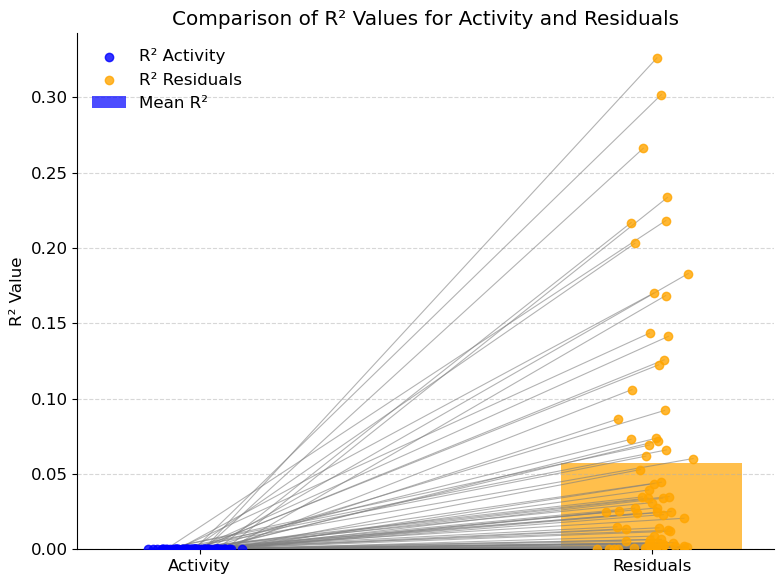

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_r2_difference_vs_velocity(r2_list_activity, r2_list_residuals):
    mean_activity = np.mean(r2_list_activity)
    mean_residuals = np.mean(r2_list_residuals)

    positions = [0, 1]

    plt.figure(figsize=(8, 6))

    plt.bar(positions, [mean_activity, mean_residuals], color=['blue', 'orange'], alpha=0.7, width=0.4, label='Mean R²')

    x_jitter_activity = np.random.normal(positions[0], 0.05, size=len(r2_list_activity))  
    x_jitter_residuals = np.random.normal(positions[1], 0.05, size=len(r2_list_residuals)) 

    plt.scatter(x_jitter_activity, r2_list_activity, color='blue', alpha=0.8, label='R² Activity', zorder=3)
    plt.scatter(x_jitter_residuals, r2_list_residuals, color='orange', alpha=0.8, label='R² Residuals', zorder=3)

    for i in range(len(r2_list_activity)):
        plt.plot([x_jitter_activity[i], x_jitter_residuals[i]],
                 [r2_list_activity[i], r2_list_residuals[i]],
                 color='gray', alpha=0.6, linewidth=0.8)


    plt.xticks(positions, ['Activity', 'Residuals'])
    plt.ylabel("R² Value")
    plt.title("Comparison of R² Values for Activity and Residuals")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)


    plt.tight_layout()
    plt.show()

plot_r2_difference_vs_velocity(r2_list_activity_zero, r2_list_residuals_zero)

In [ ]:
def plot_r2_difference_vs_velocity(r2_list_activity, r2_list_residuals):
    mean_activity = np.mean(r2_list_activity)
    mean_residuals = np.mean(r2_list_residuals)

    positions = [0, 1]

    plt.figure(figsize=(8, 6))

    plt.bar(positions, [mean_activity, mean_residuals], color=['blue', 'orange'], alpha=0.7, width=0.4, label='Mean R²')

    x_jitter_activity = np.random.normal(positions[0], 0.05, size=len(r2_list_activity))  
    x_jitter_residuals = np.random.normal(positions[1], 0.05, size=len(r2_list_residuals)) 

    plt.scatter(x_jitter_activity, r2_list_activity, color='blue', alpha=0.8, label='R² Activity', zorder=3)
    plt.scatter(x_jitter_residuals, r2_list_residuals, color='orange', alpha=0.8, label='R² Residuals', zorder=3)

    for i in range(len(r2_list_activity)):
        plt.plot([x_jitter_activity[i], x_jitter_residuals[i]],
                 [r2_list_activity[i], r2_list_residuals[i]],
                 color='gray', alpha=0.6, linewidth=0.8)


    plt.xticks(positions, ['Activity', 'Residuals'])
    plt.ylabel("R² Value")
    plt.title("Comparison of R² Values for Activity and Residuals")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)


    plt.tight_layout()
    plt.show()

plot_r2_difference_vs_velocity(r2_list_activity_zero, r2_list_residuals_zero)